In [24]:
import statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\AirPassengers.csv', index_col='Month', parse_dates=['Month'])
df.head(5)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


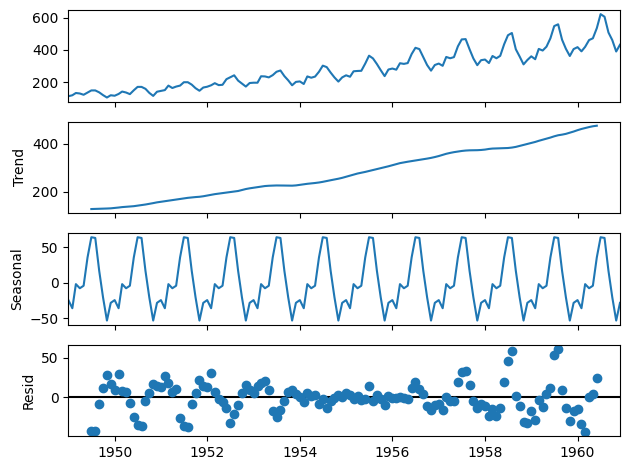

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df)
fig = decomposition.plot()
plt.show()

In [27]:
def exp_smth(x_t, a, s_t_1):
    return a * x_t + (1 - a) * s_t_1

data = np.array([15, 20, 25, 30, 25, 27])
a = 0.7
s = np.zeros(6)
s[0] = data[0]

for i in range(1, len(data)):
    s[i] = exp_smth(data[i], a, s[i-1])

print(s)

[15.      18.5     23.05    27.915   25.8745  26.66235]


In [28]:
from statsmodels.tsa.api import SimpleExpSmoothing
ses = SimpleExpSmoothing(data)
alpha = 0.7
model = ses.fit(smoothing_level=alpha, optimized=False)
forecast = model.forecast(1)
print(forecast)

[26.66235]


In [29]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv(
	r"C:\Users\user\Desktop\Skilfactory\data1\daily-total-female-births.csv", 
    header=0, 
    index_col=0
).squeeze("columns")

result = adfuller(df.values)

print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print("Critical Values:")

for key, value in result[4].items():
	print(f"\t{key}: {value:.3f}")

ADF Statistic: -4.808291253559765
p-value: 5.2434129901498554e-05
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


In [30]:
df_diff_1 = df.diff().dropna()

In [31]:
test1 = adfuller(df_diff_1)
print ('adf: ', test1[0])
print ('p-value: ', test1[1])
print ('Critical values: ', test1[4])
if test1[0]> test1[4]['5%']: 
    print ('ряд нестационарен')
else:
    print ('ряд стационарен')

adf:  -12.625178633871382
p-value:  1.5472400091966898e-23
Critical values:  {'1%': -3.44880082033912, '5%': -2.869670179576637, '10%': -2.5711012838861036}
ряд стационарен


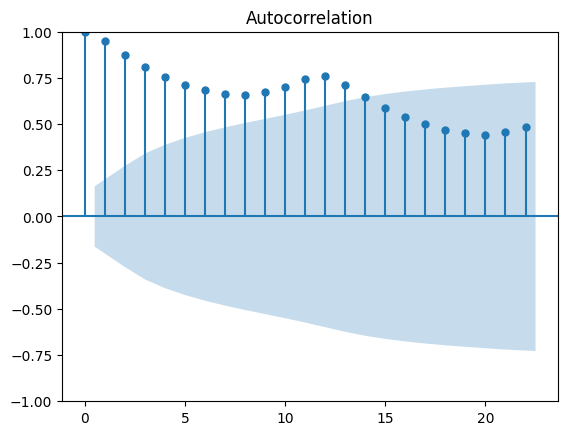

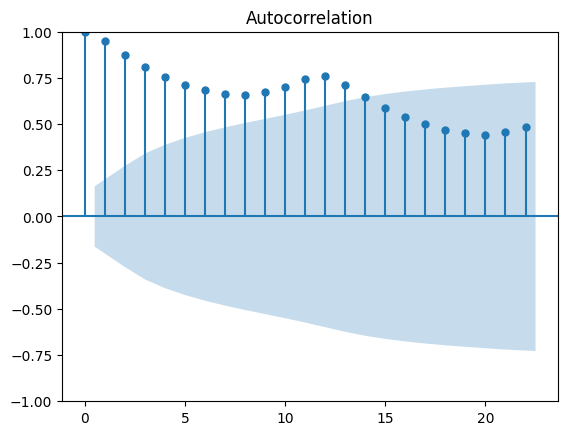

In [32]:
from statsmodels.graphics.tsaplots import plot_acf
df = pd.read_csv(r"C:\Users\user\Desktop\Skilfactory\data1\AirPassengers.csv", index_col='Month', parse_dates=['Month'])
plot_acf(df)

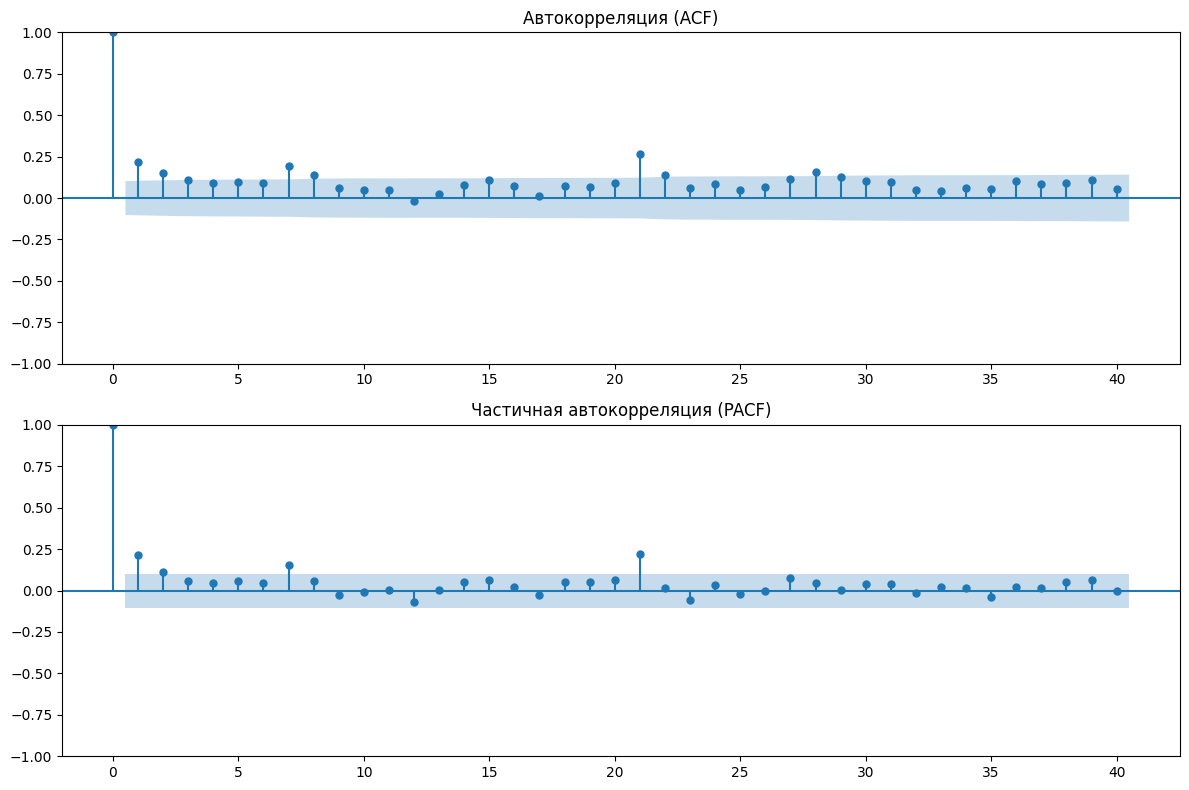

In [33]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt

# Загрузка данных
series = pd.read_csv(r"C:\Users\user\Desktop\Skilfactory\data1\daily-total-female-births.csv", 
                     header=0, 
                     index_col=0,
                     parse_dates=True).squeeze("columns")

# Строим оба графика
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title('Автокорреляция (ACF)')

# PACF
plot_pacf(series, lags=40, ax=axes[1])
axes[1].set_title('Частичная автокорреляция (PACF)')

plt.tight_layout()
plt.show()

Значения PACF:
  Lag 0: 1.0000
  Lag 1: 0.6933
  Lag 2: 0.2899
  Lag 3: 0.0442
  Lag 4: -0.0086
  Lag 5: 0.1414
  Lag 6: -0.1552
  Lag 7: -0.0575
  Lag 8: -0.0992
  Lag 9: 0.0902
  Lag 10: -0.0768


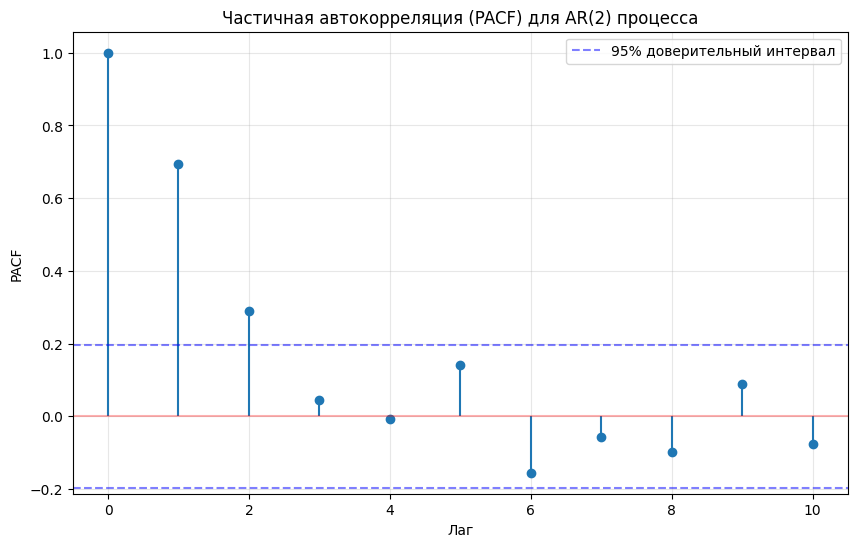

In [34]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import pacf
import matplotlib.pyplot as plt

# Создаем искусственный ряд
np.random.seed(42)
n = 100

# AR(2) процесс: X_t = 0.5*X_{t-1} + 0.3*X_{t-2} + ε
X = np.zeros(n)
for t in range(2, n):
    X[t] = 0.5*X[t-1] + 0.3*X[t-2] + 0.1*np.random.randn()

# Преобразуем в Series
series = pd.Series(X)

# Рассчитываем PACF
pacf_values = pacf(series, nlags=10, method='ols')  # ols для наглядности

print("Значения PACF:")
for lag, value in enumerate(pacf_values):
    print(f"  Lag {lag}: {value:.4f}")

# Визуализируем
plt.figure(figsize=(10, 6))
plt.stem(range(len(pacf_values)), pacf_values, basefmt=" ")
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axhline(y=1.96/np.sqrt(len(series)), color='blue', linestyle='--', alpha=0.5, label='95% доверительный интервал')
plt.axhline(y=-1.96/np.sqrt(len(series)), color='blue', linestyle='--', alpha=0.5)
plt.title('Частичная автокорреляция (PACF) для AR(2) процесса')
plt.xlabel('Лаг')
plt.ylabel('PACF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
from statsmodels.tsa.ar_model import AutoReg
url='https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv'
df = pd.read_csv(url, sep=",")

In [37]:
df

,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.18400,NaN,NaN,NaN
1,2006-01-02,1380.52100,NaN,NaN,NaN
2,2006-01-03,1442.53300,NaN,NaN,NaN
3,2006-01-04,1457.21700,NaN,NaN,NaN
4,2006-01-05,1477.13100,NaN,NaN,NaN
...,...,...,...,...,...
4378,2017-12-27,1263.94091,394.507,16.530,411.037
4379,2017-12-28,1299.86398,506.424,14.162,520.586
4380,2017-12-29,1295.08753,584.277,29.854,614.131
4381,2017-12-30,1215.44897,721.247,7.467,728.714


In [39]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Consumption'].values)

if result[0] > result[4]['5%']: 
    print ('Ряд нестационарен')
else:
    print ('Ряд стационарен')

Ряд стационарен


In [40]:
train_data = df['Consumption'][:len(df)-100]
test_data = df['Consumption'][len(df)-100:]

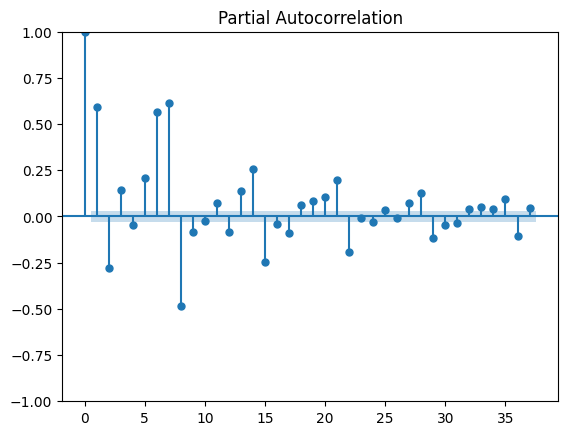

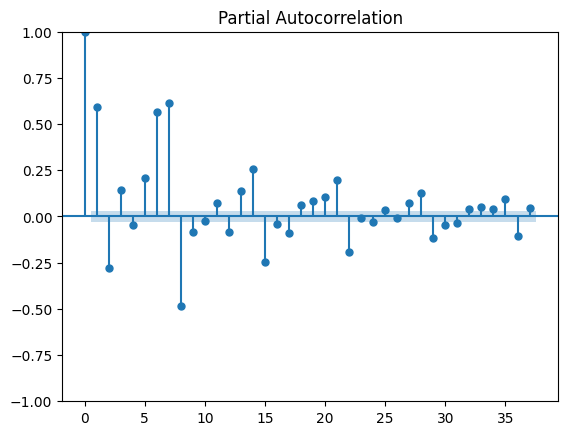

In [41]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Consumption'])

In [42]:
ar_model = AutoReg(train_data, lags=8).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:            Consumption   No. Observations:                 4283
Model:                     AutoReg(8)   Log Likelihood              -24231.812
Method:               Conditional MLE   S.D. of innovations             70.058
Date:                Thu, 05 Feb 2026   AIC                          48483.625
Time:                        12:06:39   BIC                          48547.230
Sample:                             8   HQIC                         48506.095
                                 4283                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            121.2792     14.444      8.397      0.000      92.969     149.589
Consumption.L1     0.6393      0.013     47.751      0.000       0.613       0.666
Consumption.L2    -0.0966      0.011

In [44]:
pred = ar_model.predict(start=len(train_data), end=(len(df)-1), dynamic=False)
pred

4283    1199.580761
4284    1132.051688
4285    1392.772651
4286    1425.877770
4287    1424.606502
           ...     
4378    1355.220188
4379    1359.014426
4380    1334.516355
4381    1299.851112
4382    1309.602440
Length: 100, dtype: float64